In [149]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold, cross_val_score, train_test_split
from sklearn.feature_selection import SelectKBest, f_classif
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# 0. Import database

In [150]:
url = "https://raw.githubusercontent.com/diogenesjusto/FIAP/master/dados/credit.csv"

# Importa Base, separação por tabulação
base = pd.read_csv(url, sep="\t", encoding="Latin-1")

# Cria uma lista com os nomes das colunas
header = ['ID_CLIENTE', 'TIPO_FUNCIONARIO', 'DIA_PAGAMENTO', 'TIPO_ENVIO_APLICACAO', 'QUANT_CARTOES_ADICIONAIS',
          'TIPO_ENDERECO_POSTAL', 'SEXO', 'ESTADO_CIVIL', 'QUANT_DEPENDENTES', 'NIVEL_EDUCACIONAL', 'ESTADO_NASCIMENTO',
          'CIDADE_NASCIMENTO', 'NACIONALIDADE', 'ESTADO_RESIDENCIAL', 'CIDADE_RESIDENCIAL', 'BAIRRO_RESIDENCIAL',
          'FLAG_TELEFONE_RESIDENCIAL', 'CODIGO_AREA_TELEFONE_RESIDENCIAL', 'TIPO_RESIDENCIA', 'MESES_RESIDENCIA',
          'FLAG_TELEFONE_MOVEL', 'FLAG_EMAIL', 'RENDA_PESSOAL_MENSAL', 'OUTRAS_RENDAS', 'FLAG_VISA', 'FLAG_MASTERCARD',
          'FLAG_DINERS', 'FLAG_AMERICAN_EXPRESS', 'FLAG_OUTROS_CARTOES', 'QUANT_CONTAS_BANCARIAS',
          'QUANT_CONTAS_BANCARIAS_ESPECIAIS', 'VALOR_PATRIMONIO_PESSOAL', 'QUANT_CARROS', 'EMPRESA',
          'ESTADO_PROFISSIONAL', 'CIDADE_PROFISSIONAL', 'BAIRRO_PROFISSIONAL', 'FLAG_TELEFONE_PROFISSIONAL',
          'CODIGO_AREA_TELEFONE_PROFISSIONAL', 'MESES_NO_TRABALHO', 'CODIGO_PROFISSAO', 'TIPO_OCUPACAO',
          'CODIGO_PROFISSAO_CONJUGE', 'NIVEL_EDUCACIONAL_CONJUGE', 'FLAG_DOCUMENTO_RESIDENCIAL', 'FLAG_RG',
          'FLAG_CPF', 'FLAG_COMPROVANTE_RENDA', 'PRODUTO', 'FLAG_REGISTRO_ACSP', 'IDADE', 'CEP_RESIDENCIAL_3',
          'CEP_PROFISSIONAL_3', 'ROTULO_ALVO_MAU=1'
]

# Adiciona nome as colunas do data frame
base.columns = header
base

<ipython-input-150-357b8a744636>:4: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  base = pd.read_csv(url, sep="\t", encoding="Latin-1")


,ID_CLIENTE,TIPO_FUNCIONARIO,DIA_PAGAMENTO,TIPO_ENVIO_APLICACAO,QUANT_CARTOES_ADICIONAIS,TIPO_ENDERECO_POSTAL,SEXO,ESTADO_CIVIL,QUANT_DEPENDENTES,NIVEL_EDUCACIONAL,...,FLAG_DOCUMENTO_RESIDENCIAL,FLAG_RG,FLAG_CPF,FLAG_COMPROVANTE_RENDA,PRODUTO,FLAG_REGISTRO_ACSP,IDADE,CEP_RESIDENCIAL_3,CEP_PROFISSIONAL_3,ROTULO_ALVO_MAU=1
0,2,C,15,Carga,0,1,F,2,0,0,...,0,0,0,0,1,N,34,230,230,1
1,3,C,5,Web,0,1,F,2,0,0,...,0,0,0,0,1,N,27,591,591,0
2,4,C,20,Web,0,1,F,2,0,0,...,0,0,0,0,1,N,61,545,545,0
3,5,C,10,Web,0,1,M,2,0,0,...,0,0,0,0,1,N,48,235,235,1
4,6,C,10,0,0,1,M,2,0,0,...,0,0,0,0,2,N,40,371,371,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49994,49996,C,10,0,0,1,F,1,2,0,...,0,0,0,0,1,N,36,591,591,1
49995,49997,C,25,0,0,1,F,1,0,0,...,0,0,0,0,2,N,21,186,186,0
49996,49998,C,5,Web,0,1,M,2,3,0,...,0,0,0,0,1,N,41,715,715,0
49997,49999,C,1,Web,0,1,F,1,1,0,...,0,0,0,0,1,N,28,320,320,1


In [151]:
base.to_csv("base.csv")

In [152]:
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49999 entries, 0 to 49998
Data columns (total 54 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   ID_CLIENTE                         49999 non-null  int64  
 1   TIPO_FUNCIONARIO                   49999 non-null  object 
 2   DIA_PAGAMENTO                      49999 non-null  int64  
 3   TIPO_ENVIO_APLICACAO               49999 non-null  object 
 4   QUANT_CARTOES_ADICIONAIS           49999 non-null  int64  
 5   TIPO_ENDERECO_POSTAL               49999 non-null  int64  
 6   SEXO                               49999 non-null  object 
 7   ESTADO_CIVIL                       49999 non-null  int64  
 8   QUANT_DEPENDENTES                  49999 non-null  int64  
 9   NIVEL_EDUCACIONAL                  49999 non-null  int64  
 10  ESTADO_NASCIMENTO                  49999 non-null  object 
 11  CIDADE_NASCIMENTO                  49999 non-null  obj

# 3. Teste-03

## 3.1 Tratamentos dos dados

### 3.1.1 Análise e remoção de linhas

In [153]:
# verificação dos valores da variavel SEXO
base["SEXO"].value_counts()

,count
SEXO,
F,30804
M,19130
N,48
,17


In [154]:
# Identificamos 65 linhas com valor na variavel SEXO inconsistente. Como são poucos registros optamos por remover estas linhas do modelo.

# Remoção das linhas com valor 'N'
base = base[base['SEXO'] != 'N']

# Remoção das linhas onde SEXO é nulo
base = base[base['SEXO'].notna()]

# Remoção das linhas onde SEXO é vazio
base = base[base['SEXO'].str.strip() != '']

In [155]:
# Verificação da variavel SEXO após remoção de linhas inconsistentes
base["SEXO"].value_counts()

,count
SEXO,
F,30804
M,19130


In [156]:
# verificação dos valores da variavel TIPO_RESIDENCIA
base["TIPO_RESIDENCIA"].value_counts()

,count
TIPO_RESIDENCIA,
1.0,41516
2.0,3880
5.0,1980
0.0,757
4.0,311
3.0,141


In [157]:
# verificação dos valores da variavel TIPO_ENVIO_APLICACAO
base["TIPO_ENVIO_APLICACAO"].value_counts()

,count
TIPO_ENVIO_APLICACAO,
Web,28202
0,19400
Carga,2332


In [158]:
# verificação dos valores da variavel QUANT_CARTOES_ADICIONAIS
base["QUANT_CARTOES_ADICIONAIS"].value_counts()

,count
QUANT_CARTOES_ADICIONAIS,
0,49934


In [159]:
# verificação dos valores da variavel TIPO_ENDERECO_POSTAL
base["TIPO_ENDERECO_POSTAL"].value_counts()

,count
TIPO_ENDERECO_POSTAL,
1,49607
2,327


In [160]:
# verificação dos valores da variavel ESTADO_CIVIL
base["ESTADO_CIVIL"].value_counts()

,count
ESTADO_CIVIL,
2,25929
1,15270
4,4201
6,1874
5,1294
3,632
7,534
0,200


In [161]:
# verificação dos valores da variavel QUANT_DEPENDENTES
base["QUANT_DEPENDENTES"].value_counts()

,count
QUANT_DEPENDENTES,
0,33615
1,6993
2,5352
3,2463
4,859
5,365
6,138
7,65
8,35


In [162]:
# verificação dos valores da variavel NIVEL_EDUCACIONAL
base["NIVEL_EDUCACIONAL"].value_counts()

,count
NIVEL_EDUCACIONAL,
0,49934


In [163]:
# verificação dos valores da variavel NACIONALIDADE
base["NACIONALIDADE"].value_counts()

,count
NACIONALIDADE,
1,47820
0,2016
2,98


In [164]:
# verificação dos valores da variavel MESES_RESIDENCIA
base["MESES_RESIDENCIA"].value_counts()

,count
MESES_RESIDENCIA,
1.0,7335
0.0,4687
10.0,3795
5.0,3558
2.0,3211
...,...
101.0,1
66.0,1
78.0,1


In [165]:
# verificação dos valores da variavel QUANT_CONTAS_BANCARIAS
base["QUANT_CONTAS_BANCARIAS"].value_counts()

,count
QUANT_CONTAS_BANCARIAS,
0,32111
1,17809
2,14


In [166]:
# verificação dos valores da variavel QUANT_CONTAS_BANCARIAS_ESPECIAIS
base["QUANT_CONTAS_BANCARIAS_ESPECIAIS"].value_counts()

,count
QUANT_CONTAS_BANCARIAS_ESPECIAIS,
0,32111
1,17809
2,14


In [167]:
# verificação dos valores da variavel VALOR_PATRIMONIO_PESSOAL
base["VALOR_PATRIMONIO_PESSOAL"].value_counts()

,count
VALOR_PATRIMONIO_PESSOAL,
0.0,47546
30000.0,222
25000.0,198
50000.0,196
15000.0,185
...,...
5000000.0,1
220000.0,1
53000.0,1


In [168]:
# verificação dos valores da variavel QUANT_CARROS
base["QUANT_CARROS"].value_counts()

,count
QUANT_CARROS,
0,33188
1,16746


In [169]:
# verificação dos valores da variavel CODIGO_PROFISSAO
base["CODIGO_PROFISSAO"].value_counts()

,count
CODIGO_PROFISSAO,
9.0,30052
11.0,3540
0.0,3530
2.0,2821
12.0,487
10.0,425
16.0,343
13.0,312
7.0,216


In [170]:
# verificação dos valores da variavel TIPO_OCUPACAO
base["TIPO_OCUPACAO"].value_counts()

,count
TIPO_OCUPACAO,
2.0,16926
1.0,8732
4.0,6985
5.0,6881
0.0,2779
3.0,318


In [171]:
# verificação dos valores da variavel FLAG_COMPROVANTE_RENDA
base["FLAG_COMPROVANTE_RENDA"].value_counts()

,count
FLAG_COMPROVANTE_RENDA,
0,49934


In [172]:
# verificação dos valores da variavel PRODUTO
base["PRODUTO"].value_counts()

,count
PRODUTO,
1,42633
2,6011
7,1290


### 3.1.2 Redução de dimensionalidade

In [173]:
# Consolidação das variaveis FLAG_VISA, FLAG_MASTERCARD, FLAG_DINERS, FLAG_AMERICAN_EXPRESS, FLAG_OUTROS_CARTOES
base["TEM_CARTAO"] = base[['FLAG_VISA',
                                'FLAG_MASTERCARD',
                                'FLAG_DINERS',
                                'FLAG_AMERICAN_EXPRESS',
                                'FLAG_OUTROS_CARTOES']].any(axis=1)
base["TEM_CARTAO"].value_counts()

,count
TEM_CARTAO,
False,41751
True,8183


In [174]:
# Consolidação das variaveis RENDA_PESSOAL_MENSAL e OUTRAS_RENDAS em uma nova coluna somanda ambas chamada RENDA_TOTAL, reduzindo a dimensionalidade da base
base["RENDA_TOTAL"] = base["RENDA_PESSOAL_MENSAL"] + base["OUTRAS_RENDAS"]
base["RENDA_TOTAL"].describe()

,RENDA_TOTAL
count,49934.000000
mean,922.350702
std,7902.643552
min,60.000000
25%,372.000000
50%,515.000000
75%,840.000000
max,959000.000000


In [175]:
# Listagem de variaveis que serão descartadas da base
lista_drop_features=[
    "ID_CLIENTE",
    "TIPO_FUNCIONARIO",
    "DIA_PAGAMENTO",
    "TIPO_ENVIO_APLICACAO",
    "QUANT_CARTOES_ADICIONAIS",
    "TIPO_ENDERECO_POSTAL",
    "NIVEL_EDUCACIONAL",
    "ESTADO_NASCIMENTO",
    "CIDADE_NASCIMENTO",
    "NACIONALIDADE",
    "ESTADO_RESIDENCIAL",
    "CIDADE_RESIDENCIAL",
    "BAIRRO_RESIDENCIAL",
    "BAIRRO_PROFISSIONAL",
    "FLAG_TELEFONE_RESIDENCIAL",
    "CODIGO_AREA_TELEFONE_RESIDENCIAL",
    "MESES_RESIDENCIA",
    "FLAG_TELEFONE_MOVEL",
    "FLAG_EMAIL",
    "QUANT_CONTAS_BANCARIAS_ESPECIAIS",
    "VALOR_PATRIMONIO_PESSOAL",
    #"QUANT_CARROS",
    "EMPRESA",
    "ESTADO_PROFISSIONAL",
    "CIDADE_PROFISSIONAL",
    "BAIRRO_PROFISSIONAL",
    "FLAG_TELEFONE_PROFISSIONAL",
    "CODIGO_AREA_TELEFONE_PROFISSIONAL",
    "MESES_NO_TRABALHO",
    "CODIGO_PROFISSAO",
    "CODIGO_PROFISSAO_CONJUGE",
    "NIVEL_EDUCACIONAL_CONJUGE",
    "FLAG_DOCUMENTO_RESIDENCIAL",
    "FLAG_RG",
    "FLAG_CPF",
    "FLAG_COMPROVANTE_RENDA",
    "FLAG_REGISTRO_ACSP",
    "CEP_RESIDENCIAL_3",
    "CEP_PROFISSIONAL_3",
    "QUANT_CONTAS_BANCARIAS",
    'FLAG_VISA',
    'FLAG_MASTERCARD',
    'FLAG_DINERS',
    'FLAG_AMERICAN_EXPRESS',
    'FLAG_OUTROS_CARTOES',
    "RENDA_PESSOAL_MENSAL",
    "OUTRAS_RENDAS"
    #"TIPO_RESIDENCIA"
    ]

In [176]:
# realização do drop das variaveis listadas para exclusão
base = base.drop(columns=lista_drop_features)

In [177]:
# verificação de nulos na base residual
base.isnull().sum()

,0
SEXO,0
ESTADO_CIVIL,0
QUANT_DEPENDENTES,0
TIPO_RESIDENCIA,1349
QUANT_CARROS,0
TIPO_OCUPACAO,7313
PRODUTO,0
IDADE,0
ROTULO_ALVO_MAU=1,0
TEM_CARTAO,0


In [178]:
# verificação geral da base residual
base.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49934 entries, 0 to 49998
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   SEXO               49934 non-null  object 
 1   ESTADO_CIVIL       49934 non-null  int64  
 2   QUANT_DEPENDENTES  49934 non-null  int64  
 3   TIPO_RESIDENCIA    48585 non-null  float64
 4   QUANT_CARROS       49934 non-null  int64  
 5   TIPO_OCUPACAO      42621 non-null  float64
 6   PRODUTO            49934 non-null  int64  
 7   IDADE              49934 non-null  int64  
 8   ROTULO_ALVO_MAU=1  49934 non-null  int64  
 9   TEM_CARTAO         49934 non-null  bool   
 10  RENDA_TOTAL        49934 non-null  float64
dtypes: bool(1), float64(3), int64(6), object(1)
memory usage: 4.2+ MB


### 3.1.3 Identificação e tratamento de outliers

Text(0, 0.5, 'Qte_dependentes')

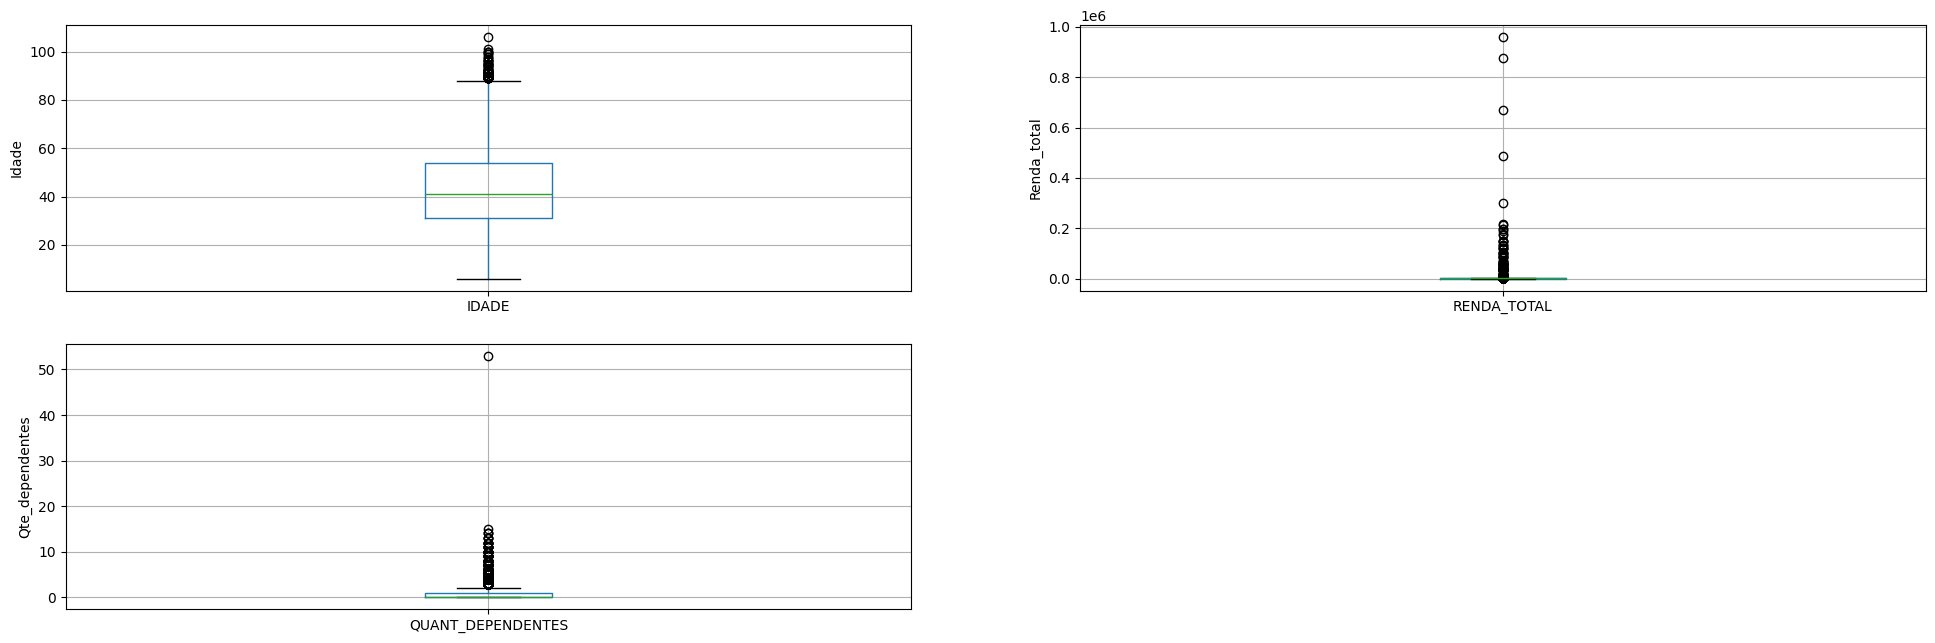

In [179]:
# criação de gráficos boxplot para identificação de possiveis outliers
plt.figure(figsize=(24,20))

plt.subplot(5, 2, 1)
fig = base.boxplot(column='IDADE')
fig.set_title('')
fig.set_ylabel('Idade')

plt.subplot(5, 2, 2)
fig = base.boxplot(column='RENDA_TOTAL')
fig.set_title('')
fig.set_ylabel('Renda_total')

plt.subplot(5, 2, 3)
fig = base.boxplot(column='QUANT_DEPENDENTES')
fig.set_title('')
fig.set_ylabel('Qte_dependentes')

In [180]:
# tratamento na variavel QUANT_DEPENDENTES para atribuir o valor teto de 7 para todos os elementos superior a 7, diminuindo a amplitude de valores
base["QUANT_DEPENDENTES"] = base["QUANT_DEPENDENTES"].apply(lambda x: 7 if x > 7 else x)
base['QUANT_DEPENDENTES'].value_counts()

,count
QUANT_DEPENDENTES,
0,33615
1,6993
2,5352
3,2463
4,859
5,365
7,149
6,138


In [181]:
# tratamento na variavel IDADE para atribuir o valor teto de 85 para todos os elementos superior a 85, diminuindo a amplitude de valores
base['IDADE'] = base['IDADE'].apply(lambda x: 85 if x > 85 else x)
base['IDADE'].value_counts()

,count
IDADE,
39,1297
36,1285
37,1265
40,1264
41,1251
...,...
84,51
17,18
6,1


Text(0, 0.5, 'Qtd_dependentes')

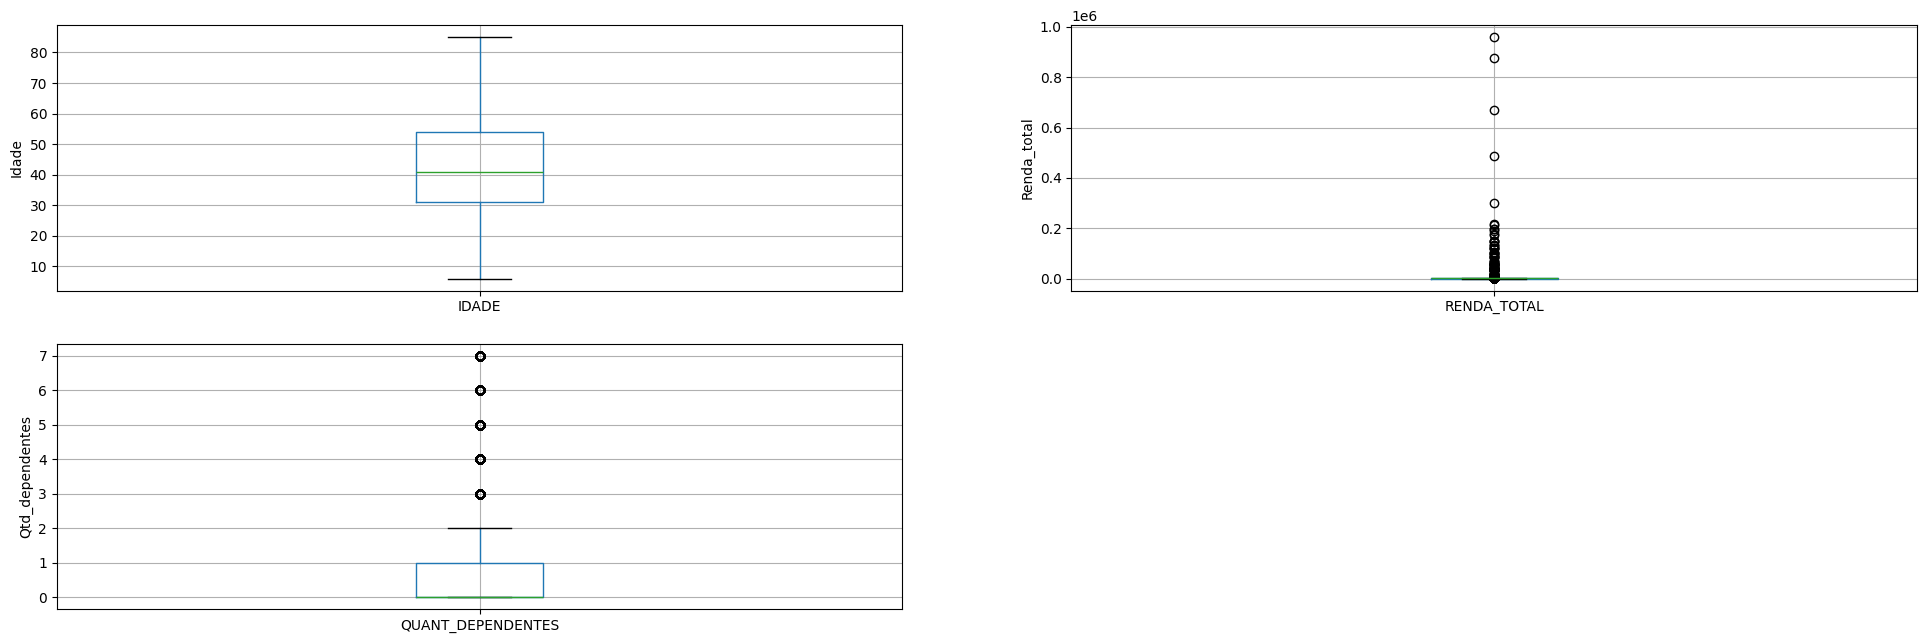

In [182]:
# análise gráfica com boxplot após tratamentos realizados
plt.figure(figsize=(24,20))

plt.subplot(5, 2, 1)
fig = base.boxplot(column='IDADE')
fig.set_title('')
fig.set_ylabel('Idade')

plt.subplot(5, 2, 2)
fig = base.boxplot(column='RENDA_TOTAL')
fig.set_title('')
fig.set_ylabel('Renda_total')

plt.subplot(5, 2, 3)
fig = base.boxplot(column='QUANT_DEPENDENTES')
fig.set_title('')
fig.set_ylabel('Qtd_dependentes')

## 3.2 Separação das bases

In [183]:
# segmentação da base em numérica e texto
base_numerica = base.select_dtypes(exclude=['object'])
base_objeto = base.select_dtypes(exclude=['int64', 'float64'])

In [184]:
# verificação da base com texto
base_objeto.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49934 entries, 0 to 49998
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   SEXO        49934 non-null  object
 1   TEM_CARTAO  49934 non-null  bool  
dtypes: bool(1), object(1)
memory usage: 829.0+ KB


In [185]:
# verificação da base numérica
base_numerica.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49934 entries, 0 to 49998
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ESTADO_CIVIL       49934 non-null  int64  
 1   QUANT_DEPENDENTES  49934 non-null  int64  
 2   TIPO_RESIDENCIA    48585 non-null  float64
 3   QUANT_CARROS       49934 non-null  int64  
 4   TIPO_OCUPACAO      42621 non-null  float64
 5   PRODUTO            49934 non-null  int64  
 6   IDADE              49934 non-null  int64  
 7   ROTULO_ALVO_MAU=1  49934 non-null  int64  
 8   TEM_CARTAO         49934 non-null  bool   
 9   RENDA_TOTAL        49934 non-null  float64
dtypes: bool(1), float64(3), int64(6)
memory usage: 3.9 MB


## 3.3 Construção do modelo

### 3.3.1 Método de criação de features

In [186]:
# Estruturação do método de criação de novas variaveis transformadas

class FeatureEngineering(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # Transformações numéricas
        X['LOG_RENDA_TOTAL'] = np.log1p(X['RENDA_TOTAL'])
        X['RENDA_POR_DEPENDENTE'] = X['RENDA_TOTAL'] / (X['QUANT_DEPENDENTES'] + 1)
        X['IDADE_RENDA'] = X['IDADE'] * X['RENDA_TOTAL']

        # Binning de idade
        X['IDADE_CAT'] = pd.cut(X['IDADE'], bins=[0, 18, 30, 45, 60, 80], labels=["0-18","18-30", "31-45", "46-60", "61-80"])
        X = X.drop(columns=['IDADE'])

        return X


### 3.3.2 Input de dados, padronização e dummificação

In [187]:
# Separando os tipos de variáveis

num_features = ['QUANT_DEPENDENTES', 'QUANT_CARROS', 'RENDA_TOTAL', 'LOG_RENDA_TOTAL', 'RENDA_POR_DEPENDENTE', 'IDADE_RENDA']
cat_features = ['ESTADO_CIVIL', 'SEXO', 'TIPO_RESIDENCIA', 'TIPO_OCUPACAO', 'PRODUTO', 'TEM_CARTAO', 'IDADE_CAT']

In [188]:
# Criação de pipelines segmentados de input e padronização

# Pipeline para variáveis numéricas
num_pipeline = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),    # Imputação com KNN
    ('scaler', StandardScaler())               # Padronização com StandardScaler
])

# Pipeline para variáveis categóricas
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),   # Preencher nulos com a moda
    ('encoder', OneHotEncoder(drop='first'))                # Dummificação de variaveis
])

# Combinando tudo
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

### 3.3.3 Construção do pipeline de execução

In [189]:
# estruturação do pipeline com as etapas do processo
pipeline = ImbPipeline([
    ('feature_engineering', FeatureEngineering()),                  # Criação de novas features
    ('preprocessing', preprocessor),                                # Aplicação de input de dados, padronização e dummificação
    ('smote', SMOTE(random_state=42)),                              # Balanceamento das classes
    ('feature_selection', SelectKBest(score_func=f_classif, k=10)), # Seleção das melhores features
    ('model', LogisticRegression(max_iter=1000))                    # definição do algoritmo
])

### 3.3.4 Definição e otimização de parametros com GridSearch

In [190]:
# Definindo o GridSearchCV para otimização de parâmetros
param_grid = {
    'model__C': [0.01, 0.1, 1, 10],           # Testando diferentes valores para C (regularização)
    'feature_selection__k': [8, 10, 12, 14]   # Testando diferentes números de features selecionadas
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='recall',      # Foco no recall
    cv=5,                  # 5-fold cross-validation
    n_jobs=-1,             # Usar todos os núcleos de processamento
    verbose=2
)

### 3.3.5 Segmentação base treino e teste

In [191]:
# segmentação em base de treino e teste
X = base.drop(columns=['ROTULO_ALVO_MAU=1'])
y = base['ROTULO_ALVO_MAU=1']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


### 3.3.6 Treino com GridSearch

In [192]:
# Treinando o modelo com GridSearch para otimização de parametros
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('feature_engineering',
                                        FeatureEngineering()),
                                       ('preprocessing',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          KNNImputer()),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['QUANT_DEPENDENTES',
                                                                          'QUANT_CARROS',
                                                                          'RENDA_TOTAL',
                                                                          'LOG_RENDA_TOTAL',
                                                                          'RENDA_POR_DEPENDENTE',
                                                                          'IDADE_RENDA']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('im...
                                                                                          OneHotEncoder(drop='first'))]),
                                                                         ['ESTADO_CIVIL',
                                                                          'SEXO',
                                                                          'TIPO_RESIDENCIA',
                                                                          'TIPO_OCUPACAO',
                                                                          'PRODUTO',
                                                                          'TEM_CARTAO',
                                                                          'IDADE_CAT'])])),
                                       ('smote', SMOTE(random_state=42)),
                                       ('feature_selection', SelectKBest()),
                                       ('model',
                                        LogisticRegression(max_iter=1000))]),
             n_jobs=-1,
             param_grid={'feature_selection__k': [8, 10, 12, 14],
                         'model__C': [0.01, 0.1, 1, 10]},
             scoring='recall', verbose=2)

### 3.3.6 Treino de cross-validation do modelo LogisticRegression

In [193]:
# Treinando o pipeline
pipeline.fit(X_train, y_train)

# Avaliando com cross-validation
recall_cv = cross_val_score(pipeline, X_train, y_train, scoring='recall', cv=5)
print(f'Recall médio na validação cruzada: {recall_cv.mean():.4f}')

Recall médio na validação cruzada: 0.6354


### 3.3.7 Avaliação dos resultados de treino e teste do modelo LogisticRegression


=== Avaliação: Pipeline Completo ===
              precision    recall  f1-score   support

    Classe 0       0.79      0.49      0.60     11147
    Classe 1       0.30      0.62      0.40      3834

    accuracy                           0.52     14981
   macro avg       0.54      0.56      0.50     14981
weighted avg       0.66      0.52      0.55     14981

Recall da classe 1: 62.42%


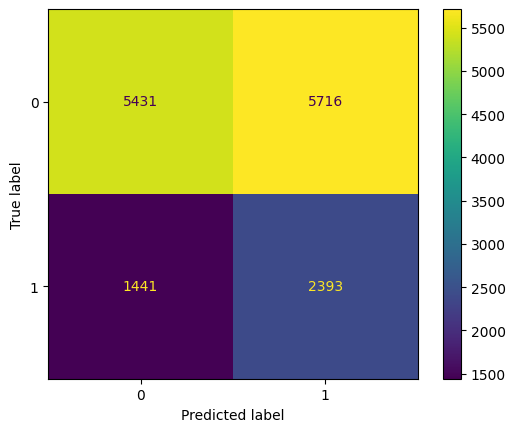

In [194]:
# Avaliação e Exibição dos Resultados

# Previsões do modelo completo
y_pred_pipeline = grid_search.predict(X_test)

# Função para avaliar o modelo (Matriz de Confusão + Relatório de Métricas)
def avaliar_modelo(y_true, y_pred, titulo):
    print(f"\n=== Avaliação: {titulo} ===")

    # Matriz de confusão
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot()

    # Classification report
    report = classification_report(y_true, y_pred, target_names=['Classe 0', 'Classe 1'])
    print(report)

    TP = cm[1, 1]  # Verdadeiros Positivos (linha 1, coluna 1)
    FN = cm[1, 0]  # Falsos Negativos (linha 1, coluna 0)

    recall_classe_1 = TP / (TP + FN)

    print(f"Recall da classe 1: {recall_classe_1:.2%}")

# Avaliação do pipeline completo
avaliar_modelo(y_test, y_pred_pipeline, "Pipeline Completo")


In [195]:
# Exibindo as Variáveis Selecionadas e Parâmetros Ideais

# Para pegar as variáveis corretamente após OneHotEncoder e SelectKBest
column_transformer = grid_search.best_estimator_.named_steps['preprocessing']

# Acessando o encoder no segundo transformer, que é o de variáveis categóricas
encoder = column_transformer.transformers_[1][1]  # O [1][1] pega o OneHotEncoder

# Obtendo os nomes das variáveis geradas pelo OneHotEncoder
encoded_cat_features = encoder.get_feature_names_out()

# Variáveis selecionadas com base no 'k' do SelectKBest
column_names = num_features + list(encoded_cat_features)
selected_indices = grid_search.best_estimator_.named_steps['feature_selection'].get_support(indices=True)
selected_features = [column_names[i] for i in selected_indices]

print("\nVariáveis Selecionadas pelo Feature Selection (SelectKBest):")
print(selected_features)

# Melhor parâmetro encontrado pelo GridSearch
print("\nMelhores Parâmetros Encontrados pelo GridSearchCV:")
print(grid_search.best_params_)

# Importância das variáveis no modelo de regressão logística
model = grid_search.best_estimator_.named_steps['model']
importances = model.coef_[0]  # Coeficientes para a classe positiva (target = 1)

# Normalizando a importância para somar 100%
importances_normalized = (importances - np.min(importances)) / (np.max(importances) - np.min(importances)) * 100

# Criando um DataFrame com as variáveis e suas importâncias
importance_df = pd.DataFrame({
    'Feature': selected_features,
    'Importance (%)': importances_normalized,
    'Importance': importances
})

# Ordenando por importância
importance_df = importance_df.sort_values(by='Importance (%)', ascending=False)

# Calculando o percentual individual
#total_importance = importance_df['Importance (%)'].sum()
#importance_df['Individual Percentage (%)'] = (importance_df['Importance (%)'] / total_importance) * 100

# Exibindo a tabela de importâncias com o percentual individual
print("\nImportância das Variáveis (em %):")
print(importance_df)

# Explicando as escolhas do GridSearch
print("\nMotivo da Escolha dos Parâmetros:")
print("""
- O parâmetro 'model__C' ajusta a regularização no modelo de regressão logística.
  Valores mais baixos de 'C' significam mais regularização (redução do overfitting), enquanto valores mais altos permitem maior flexibilidade.
  O valor ótimo encontrado indica o equilíbrio entre viés e variância.

- O parâmetro 'feature_selection__k' determina o número de features selecionadas. O GridSearch seleciona a quantidade de features que maximiza o recall.
  O valor ótimo encontrado indica o número de features mais relevantes para o modelo, garantindo que ele utilize apenas as variáveis mais informativas.
""")



Variáveis Selecionadas pelo Feature Selection (SelectKBest):
['ESTADO_CIVIL_1', 'ESTADO_CIVIL_2', 'ESTADO_CIVIL_4', 'TIPO_OCUPACAO_1.0', 'TEM_CARTAO_True', 'IDADE_CAT_18-30', 'IDADE_CAT_46-60', 'IDADE_CAT_61-80']

Melhores Parâmetros Encontrados pelo GridSearchCV:
{'feature_selection__k': 8, 'model__C': 1}

Importância das Variáveis (em %):
             Feature  Importance (%)  Importance
0     ESTADO_CIVIL_1      100.000000    0.208759
5    IDADE_CAT_18-30       94.884778    0.170331
2     ESTADO_CIVIL_4       83.658514    0.085996
1     ESTADO_CIVIL_2       72.387587    0.001326
3  TIPO_OCUPACAO_1.0       58.804864   -0.100712
4    TEM_CARTAO_True       43.694084   -0.214229
6    IDADE_CAT_46-60       29.468343   -0.321097
7    IDADE_CAT_61-80        0.000000   -0.542472

Motivo da Escolha dos Parâmetros:

- O parâmetro 'model__C' ajusta a regularização no modelo de regressão logística.
  Valores mais baixos de 'C' significam mais regularização (redução do overfitting), enquanto val